## **Zadanie 1.1**



In [87]:
# Montowanie Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
# Wczytanie danych Iris
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Liczba próbek (X): {X.shape[0]}")
print(f"Liczba cech (X): {X.shape[1]}")
print(f"Liczba klas (y): {len(target_names)}")

Liczba próbek (X): 150
Liczba cech (X): 4
Liczba klas (y): 3


In [90]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

In [91]:
print("Statystyki opisowe cech")
print(df[feature_names].describe())

Statystyki opisowe cech
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [92]:
print("Przykładowe 5 wierszy danych")
print(df.head())

Przykładowe 5 wierszy danych
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [93]:
# Podział danych na zbiory: treningowy, walidacyjny i testowy

test_size = 0.20
validation_size = 0.20
train_size = 1.0 - test_size - validation_size

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(test_size + validation_size), random_state=42, stratify=y
)

val_test_ratio = validation_size / (test_size + validation_size)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=val_test_ratio, random_state=42, stratify=y_temp
)

In [94]:
print("Rozmiary zbiorów po podziale (60/20/20)")
print(f"Zbiór treningowy: X_train.shape = {X_train.shape}, y_train.shape = {y_train.shape}")
print(f"Zbiór walidacyjny: X_val.shape = {X_val.shape}, y_val.shape = {y_val.shape}")
print(f"Zbiór testowy: X_test.shape = {X_test.shape}, y_test.shape = {y_test.shape}")

total_samples = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"Suma próbek: {total_samples} (Oryginalnie: {X.shape[0]})")

Rozmiary zbiorów po podziale (60/20/20)
Zbiór treningowy: X_train.shape = (90, 4), y_train.shape = (90,)
Zbiór walidacyjny: X_val.shape = (30, 4), y_val.shape = (30,)
Zbiór testowy: X_test.shape = (30, 4), y_test.shape = (30,)
Suma próbek: 150 (Oryginalnie: 150)


In [95]:
scaler = StandardScaler()
scaler.fit(X_train)

# Transformacja zbiorów
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [96]:
print("Statystyki po standaryzacji (X_train_scaled)")
df_scaled = pd.DataFrame(X_train_scaled, columns=feature_names)
print(df_scaled.describe())

Statystyki po standaryzacji (X_train_scaled)
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count       9.000000e+01      9.000000e+01       9.000000e+01   
mean       -7.475502e-16     -6.442377e-16      -5.649802e-16   
std         1.005602e+00      1.005602e+00       1.005602e+00   
min        -1.830263e+00     -2.275952e+00      -1.519624e+00   
25%        -8.671375e-01     -5.654244e-01      -1.279832e+00   
50%        -1.374967e-01     -1.377925e-01       2.294482e-01   
75%         6.213296e-01      6.640173e-01       7.372434e-01   
max         2.372467e+00      2.855631e+00       1.752834e+00   

       petal width (cm)  
count      9.000000e+01  
mean       2.491834e-16  
std        1.005602e+00  
min       -1.433868e+00  
25%       -1.173952e+00  
50%        1.256259e-01  
75%        8.728835e-01  
max        1.685120e+00  


## **Zadanie 1.2**



In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

In [98]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Tworzenie obiektów Dataset i DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

In [99]:
class SimpleClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleClassifier, self).__init__()

        # warstwy (dwie ukryte)
        self.layer_1 = nn.Linear(input_size, hidden_size)
        self.layer_2 = nn.Linear(hidden_size, hidden_size)
        self.output_layer = nn.Linear(hidden_size, num_classes)

        # funkcja aktywacji
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.layer_1(x)
        out = self.relu(out)

        out = self.layer_2(out)
        out = self.relu(out)

        out = self.output_layer(out)
        return out

# Inicjalizacja modelu
input_size = X_train_scaled.shape[1]
hidden_size = 16
num_classes = len(np.unique(y_train))

model = SimpleClassifier(input_size, hidden_size, num_classes)

print("Architektura Modelu PyTorch")
print(model)

Architektura Modelu PyTorch
SimpleClassifier(
  (layer_1): Linear(in_features=4, out_features=16, bias=True)
  (layer_2): Linear(in_features=16, out_features=16, bias=True)
  (output_layer): Linear(in_features=16, out_features=3, bias=True)
  (relu): ReLU()
)


In [100]:
learning_rate = 0.005
num_epochs = 50

# Funkcja straty
criterion = nn.CrossEntropyLoss()

# Optymalizator
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_loss_history = []
train_accuracy_history = []
val_loss_history = []
val_accuracy_history = []

print(f"Trening Modelu (Epok: {num_epochs}, LR: {learning_rate})")

# Pętla treningowa
for epoch in range(num_epochs):
    model.train()

    total_train_loss = 0
    correct_train = 0
    total_train = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_loss_history.append(avg_train_loss)
    train_accuracy = correct_train / total_train
    train_accuracy_history.append(train_accuracy)

    # Walidacja
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor).item()
        val_loss_history.append(val_loss)

        _, predicted_val = torch.max(val_outputs.data, 1)
        val_accuracy = (predicted_val == y_val_tensor).sum().item() / y_val_tensor.size(0)
        val_accuracy_history.append(val_accuracy)

    if (epoch + 1) % 10 == 0 or epoch == 0 or epoch == num_epochs - 1:
        print(f'Epoka [{epoch+1}/{num_epochs}], '
              f'Loss Treningowy: {avg_train_loss:.4f}, Acc Treningowa: {train_accuracy:.4f}, '
              f'Loss Walidacyjny: {val_loss:.4f}, Acc Walidacyjna: {val_accuracy:.4f}')

print("Trening zakończony!")

Trening Modelu (Epok: 50, LR: 0.005)
Epoka [1/50], Loss Treningowy: 1.0089, Acc Treningowa: 0.4778, Loss Walidacyjny: 0.9212, Acc Walidacyjna: 0.7333
Epoka [10/50], Loss Treningowy: 0.0982, Acc Treningowa: 0.9667, Loss Walidacyjny: 0.1407, Acc Walidacyjna: 0.9667
Epoka [20/50], Loss Treningowy: 0.0507, Acc Treningowa: 0.9778, Loss Walidacyjny: 0.0661, Acc Walidacyjna: 1.0000
Epoka [30/50], Loss Treningowy: 0.0378, Acc Treningowa: 0.9889, Loss Walidacyjny: 0.0563, Acc Walidacyjna: 0.9667
Epoka [40/50], Loss Treningowy: 0.0371, Acc Treningowa: 0.9778, Loss Walidacyjny: 0.0593, Acc Walidacyjna: 0.9667
Epoka [50/50], Loss Treningowy: 0.0479, Acc Treningowa: 0.9778, Loss Walidacyjny: 0.0422, Acc Walidacyjna: 1.0000
Trening zakończony!


In [101]:
model.eval()

with torch.no_grad():
    test_outputs = model(X_test_tensor)

    test_loss = criterion(test_outputs, y_test_tensor).item()

    _, predicted_test = torch.max(test_outputs.data, 1)
    correct_test = (predicted_test == y_test_tensor).sum().item()
    total_test = y_test_tensor.size(0)
    test_accuracy = correct_test / total_test

print(f"Ocena na Zbiorze Testowym")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({correct_test}/{total_test} poprawnych)")

Ocena na Zbiorze Testowym
Test Loss: 0.1861
Test Accuracy: 0.9000 (27/30 poprawnych)


In [102]:
results_history = {
    'train_loss': train_loss_history,
    'val_loss': val_loss_history,
    'train_accuracy': train_accuracy_history,
    'val_accuracy': val_accuracy_history,
    'test_predictions': predicted_test.numpy(),
    'test_true': y_test_tensor.numpy()
}

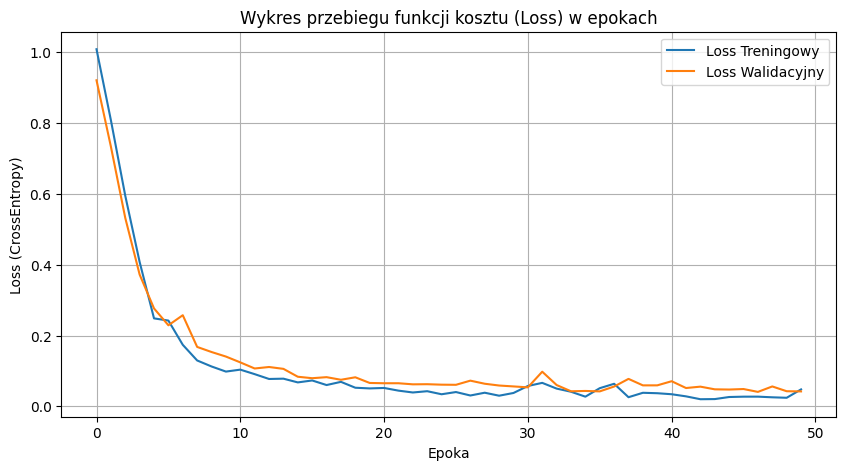

In [103]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(results_history['train_loss'], label='Loss Treningowy')
plt.plot(results_history['val_loss'], label='Loss Walidacyjny')
plt.title('Wykres przebiegu funkcji kosztu (Loss) w epokach')
plt.xlabel('Epoka')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)
plt.show()

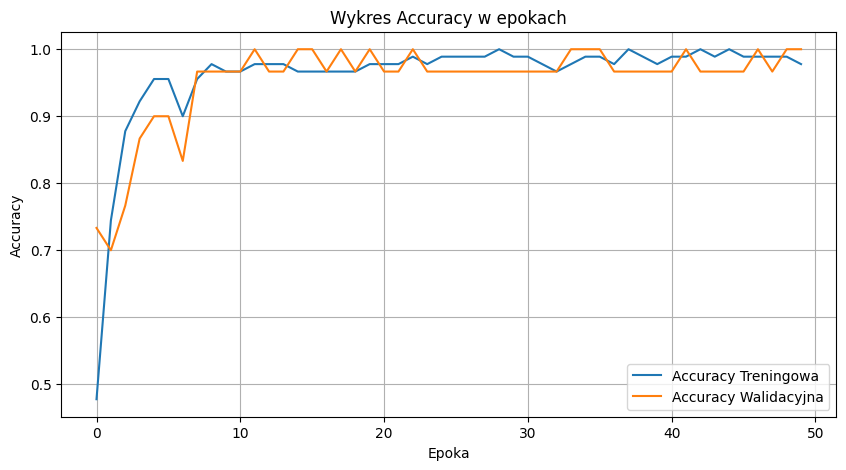

In [104]:
plt.figure(figsize=(10, 5))
plt.plot(results_history['train_accuracy'], label='Accuracy Treningowa')
plt.plot(results_history['val_accuracy'], label='Accuracy Walidacyjna')
plt.title('Wykres Accuracy w epokach')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# **Zadanie 1.3**


In [106]:
learning_rate = 0.005
num_epochs = 50
batch_size = 8
input_size = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))

In [107]:
class ModelA(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class ModelB(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        return self.net(x)

class ModelC(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [108]:
def train_and_evaluate(model, train_loader, X_test_tensor, y_test_tensor, num_epochs, lr):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Trening
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Ewaluacja na zbiorze testowym
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()

        _, predicted = torch.max(test_outputs.data, 1)
        test_accuracy = (predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)

        cm = confusion_matrix(y_test_tensor.numpy(), predicted.numpy())

    return test_loss, test_accuracy, cm

model_a = ModelA(input_size, 16, num_classes)
model_b = ModelB(input_size, 32, num_classes)
model_c = ModelC(input_size, 8, num_classes)

models = {
    "A (Bazowy: 2x16, ReLU)": model_a,
    "B (Płytki/Szeroki: 1x32, ReLU)": model_b,
    "C (Głęboki: 3x8, Tanh)": model_c
}

results = {}

print("Rozpoczęcie eksperymentów z architekturami")

for name, model in models.items():
    print(f"Trenowanie: {name}...")
    loss, acc, cm = train_and_evaluate(
        model,
        train_loader,
        X_test_tensor,
        y_test_tensor,
        num_epochs,
        learning_rate
    )
    results[name] = {'Loss Test': loss, 'Accuracy Test': acc, 'Confusion Matrix': cm}
    print(f"  -> Wynik Accuracy Test: {acc:.4f}")

print("Eksperymenty zakończone")

Rozpoczęcie eksperymentów z architekturami
Trenowanie: A (Bazowy: 2x16, ReLU)...
  -> Wynik Accuracy Test: 0.9333
Trenowanie: B (Płytki/Szeroki: 1x32, ReLU)...
  -> Wynik Accuracy Test: 0.9667
Trenowanie: C (Głęboki: 3x8, Tanh)...
  -> Wynik Accuracy Test: 0.9333
Eksperymenty zakończone


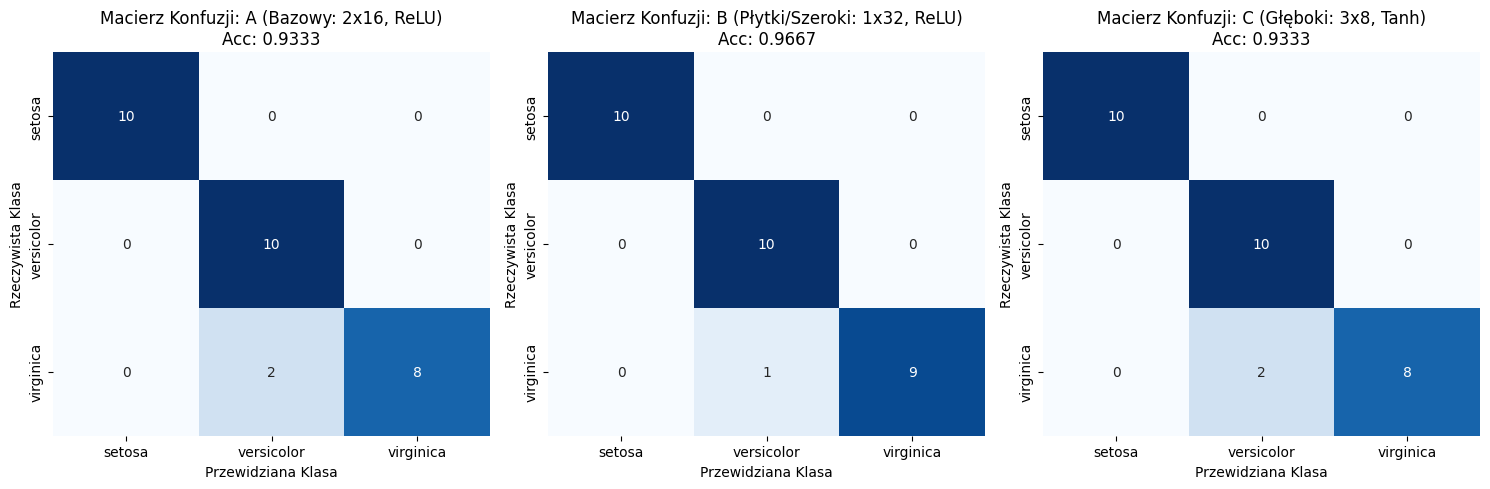

In [109]:
# Macierz Konfuzji dla każdego modelu
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = list(results.keys())

for i, name in enumerate(titles):
    cm = results[name]['Confusion Matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[i],
                xticklabels=iris.target_names, yticklabels=iris.target_names)
    axes[i].set_title(f'Macierz Konfuzji: {name}\nAcc: {results[name]["Accuracy Test"]:.4f}')
    axes[i].set_xlabel('Przewidziana Klasa')
    axes[i].set_ylabel('Rzeczywista Klasa')

plt.tight_layout()
plt.show()

# **Zadanie 1.4**

In [110]:
# Przyjmujemy model A (2x16, ReLU) jako nasz model bazowy
class ModelA(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, num_classes)
        )
    def forward(self, x):
        return self.net(x)

input_size = X_train_scaled.shape[1]
num_classes = len(np.unique(y_train))
hidden_size = 16
num_epochs = 50

In [111]:
def train_and_evaluate_hp(model, train_loader, X_test_tensor, y_test_tensor, num_epochs, lr, optimizer_type='Adam'):
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=lr)
    elif optimizer_type == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=lr)
    else:
        raise ValueError("Nieznany optymalizator")

    # Trening
    for epoch in range(num_epochs):
        model.train()
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    # Ewaluacja na zbiorze testowym
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()
        _, predicted = torch.max(test_outputs.data, 1)
        test_accuracy = (predicted == y_test_tensor).sum().item() / y_test_tensor.size(0)

    return test_loss, test_accuracy

In [112]:
hyperparam_results = {}
configurations = [
    ('Konf. 1 (Bazowa)', 0.005, 'Adam'),
    ('Konf. 2 (Niskie LR)', 0.0005, 'Adam'),
    ('Konf. 3 (Wysokie LR)', 0.05, 'Adam'),
    ('Konf. 4 (Opt. SGD)', 0.005, 'SGD'),
]

print("--- Rozpoczęcie eksperymentów z hiperparametrami ---")

for name, lr, opt_type in configurations:
    model = ModelA(input_size, hidden_size, num_classes)

    print(f"Trenowanie: {name} (LR: {lr}, Opt: {opt_type})...")

    loss, acc = train_and_evaluate_hp(
        model,
        train_loader,
        X_test_tensor,
        y_test_tensor,
        num_epochs,
        lr,
        opt_type
    )
    hyperparam_results[name] = {'LR': lr, 'Optimizator': opt_type, 'Loss Test': loss, 'Accuracy Test': acc}
    print(f"  -> Wynik Accuracy Test: {acc:.4f}")

print("Eksperymenty zakończone")

--- Rozpoczęcie eksperymentów z hiperparametrami ---
Trenowanie: Konf. 1 (Bazowa) (LR: 0.005, Opt: Adam)...
  -> Wynik Accuracy Test: 0.9333
Trenowanie: Konf. 2 (Niskie LR) (LR: 0.0005, Opt: Adam)...
  -> Wynik Accuracy Test: 0.9000
Trenowanie: Konf. 3 (Wysokie LR) (LR: 0.05, Opt: Adam)...
  -> Wynik Accuracy Test: 0.9333
Trenowanie: Konf. 4 (Opt. SGD) (LR: 0.005, Opt: SGD)...
  -> Wynik Accuracy Test: 0.8000
Eksperymenty zakończone


Tabela Porównawcza Hiperparametrów
|                      |     LR | Optimizator   |   Loss Test |   Accuracy Test |
|:---------------------|-------:|:--------------|------------:|----------------:|
| Konf. 1 (Bazowa)     | 0.005  | Adam          |    0.14025  |        0.933333 |
| Konf. 2 (Niskie LR)  | 0.0005 | Adam          |    0.318878 |        0.9      |
| Konf. 3 (Wysokie LR) | 0.05   | Adam          |    0.191662 |        0.933333 |
| Konf. 4 (Opt. SGD)   | 0.005  | SGD           |    0.513862 |        0.8      |


/tmp/ipython-input-3113914067.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Konfiguracja', y='Accuracy Test', data=df_hp, palette='viridis')


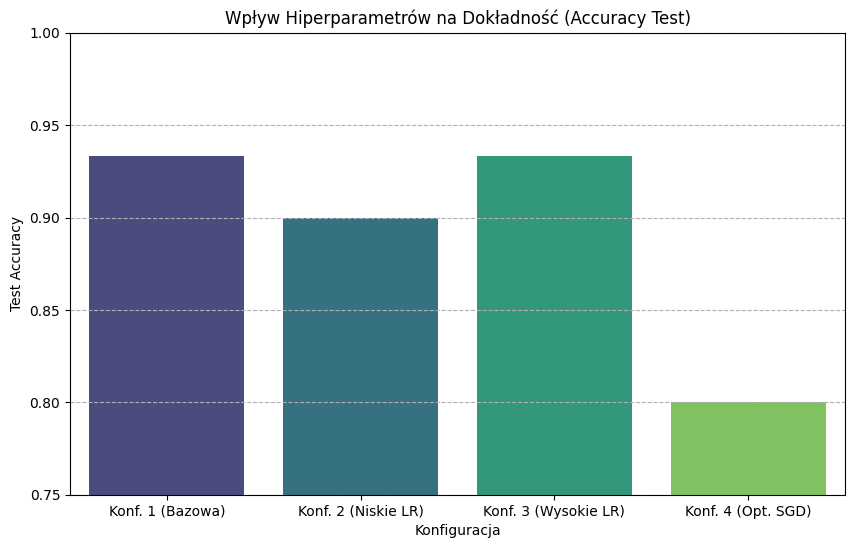

In [113]:
df_hp = pd.DataFrame.from_dict(hyperparam_results, orient='index')
df_hp['Konfiguracja'] = df_hp.index

print("Tabela Porównawcza Hiperparametrów")
print(df_hp[['LR', 'Optimizator', 'Loss Test', 'Accuracy Test']].to_markdown())

plt.figure(figsize=(10, 6))
sns.barplot(x='Konfiguracja', y='Accuracy Test', data=df_hp, palette='viridis')
plt.title('Wpływ Hiperparametrów na Dokładność (Accuracy Test)')
plt.ylabel('Test Accuracy')
plt.ylim(df_hp['Accuracy Test'].min() - 0.05, 1.0)
plt.grid(axis='y', linestyle='--')
plt.show()

# **Wpływ zmian hiperparametrów na wynik**


1. Wpływ Współczynnika Uczenia (LR) przy Optymalizatorze Adam
Średnie i Wysokie LR (Konf. 1 i 3):

 Zarówno bazowe LR=0.005, jak i wyższe LR=0.05, osiągnęły tę samą, wysoką dokładność testową (≈93.33%). Wyższe LR (Konf. 3) dało minimalnie gorszy Loss, ale potwierdza, że Adam jest dość tolerancyjny na duży krok uczenia w tym problemie.

Niskie LR (Konf. 2): Zmniejszenie LR do 0.0005 spowodowało spadek dokładności do 90.00% i największy Loss (≈0.319). Sugeruje to, że model nie zdążył się w pełni zbiec do optymalnego minimum w ciągu 50 epok ze względu na zbyt małe kroki uczenia.

2. Wpływ Optymalizatora (Adam vs. SGD)

Optymalizator Adam (Konf. 1 i 3) okazał się bardziej efektywny i stabilny, konsekwentnie osiągając dokładność 93.33% przy niskim Loss.
Optymalizator SGD (Konf. 4) przy takim samym LR=0.005 uzyskał najgorszy wynik w eksperymencie (Accuracy=80.00%) z bardzo wysokim Loss (≈0.514). W tym przypadku, Adam lepiej poradził sobie z konwergencją przy domyślnych parametrach, a SGD wymagałby prawdopodobnie dużo wyższego LR lub większej liczby epok.